# Train: Sigmoid Attention (No Gate)
GPT-2 12L with sigmoid attention, QK RMSNorm, and dynamic positional bias $b_t = -\log(t+1)$.

In [ ]:
import os, math, time, random
from dataclasses import dataclass, asdict
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

from google.colab import drive
drive.mount('/content/drive')

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Mounted at /content/drive
Device: cuda


In [ ]:
@dataclass
class Config:
    d_model: int = 768
    n_layer: int = 12
    n_head: int = 12
    d_ff: int = 3072
    block_size: int = 512
    vocab_size: int = 50257

    batch_size: int = 64
    lr: float = 6e-4
    weight_decay: float = 0.01
    grad_clip: float = 1.0
    warmup_ratio: float = 0.067
    epochs: int = 3
    eval_every: int = 1000

    base_dir: str = "/content/drive/MyDrive/SigEvict"
    smoke: bool = False

    exp_name: str = "gpt2_12L_sigmoid_no_gate_norope"

cfg = Config()
cfg.data_dir = os.path.join(cfg.base_dir, "data")
cfg.save_dir = os.path.join(cfg.base_dir, "models")
cfg.results_dir = os.path.join(cfg.base_dir, "results")
os.makedirs(cfg.save_dir, exist_ok=True)
os.makedirs(cfg.results_dir, exist_ok=True)

if cfg.smoke:
    cfg.epochs = 1
    cfg.eval_every = 500
# === Copy data to local for speed ===
import shutil
LOCAL_DATA = "/content/local_data"
os.makedirs(LOCAL_DATA, exist_ok=True)

for fname in ["owt_train_1B.pt", "owt_val_100K.pt"]:
    src = os.path.join(cfg.data_dir, fname)
    dst = os.path.join(LOCAL_DATA, fname)
    if not os.path.exists(dst):
        print(f"Copying {fname} to local SSD...")
        shutil.copy(src, dst)
        print(f"  Done: {os.path.getsize(dst)/1e9:.2f} GB")

cfg.data_dir = LOCAL_DATA  # Use local path
print(f"Data dir: {cfg.data_dir}")


Copying owt_train_1B.pt to local SSD...
  Done: 8.00 GB
Copying owt_val_100K.pt to local SSD...
  Done: 0.00 GB
Data dir: /content/local_data


In [ ]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")
train_tokens = torch.load(os.path.join(cfg.data_dir, "owt_train_1B.pt"), weights_only=True)
val_tokens = torch.load(os.path.join(cfg.data_dir, "owt_val_100K.pt"), weights_only=True)

class TokenDataset(Dataset):
    def __init__(self, tokens, block_size):
        self.tokens, self.block_size = tokens, block_size
    def __len__(self): return (len(self.tokens) - 1) // self.block_size
    def __getitem__(self, i):
        s = i * self.block_size
        return self.tokens[s:s+self.block_size], self.tokens[s+1:s+self.block_size+1]

shuffle_gen = torch.Generator()
shuffle_gen.manual_seed(SEED)
train_ds = TokenDataset(train_tokens, cfg.block_size)
val_ds = TokenDataset(val_tokens, cfg.block_size)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                          drop_last=True, generator=shuffle_gen, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size,
                        drop_last=True, num_workers=2, pin_memory=True)

cfg.max_steps = len(train_loader) * cfg.epochs
cfg.warmup_steps = int(cfg.max_steps * cfg.warmup_ratio)
if cfg.smoke:
    cfg.max_steps = min(cfg.max_steps, 2000)
    cfg.warmup_steps = min(cfg.warmup_steps, 200)
print(f"Train: {len(train_ds):,} seqs, {len(train_loader):,} batches/epoch")
print(f"Val: {len(val_ds):,} seqs")
print(f"Max steps: {cfg.max_steps:,}, warmup: {cfg.warmup_steps:,}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train: 1,953,124 seqs, 30,517 batches/epoch
Val: 195 seqs
Max steps: 91,551, warmup: 6,133


In [ ]:
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps, self.weight = eps, nn.Parameter(torch.ones(dim))
    def forward(self, x):
        return x / torch.sqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.weight

class MLP(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.fc = nn.Linear(cfg.d_model, cfg.d_ff, bias=False)
        self.proj = nn.Linear(cfg.d_ff, cfg.d_model, bias=False)
    def forward(self, x):
        return self.proj(F.gelu(self.fc(x)))

In [ ]:
class SigmoidAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.n_head, self.d_head = cfg.n_head, cfg.d_model // cfg.n_head
        self.c_attn = nn.Linear(cfg.d_model, 3 * cfg.d_model, bias=False)
        self.c_proj = nn.Linear(cfg.d_model, cfg.d_model, bias=False)
        self.scale = 1.0 / math.sqrt(self.d_head)
        self.q_norm, self.k_norm = RMSNorm(self.d_head), RMSNorm(self.d_head)
        self.register_buffer("mask", torch.triu(torch.ones(cfg.block_size, cfg.block_size), diagonal=1).bool())
        self.register_buffer("pos_bias", -torch.log(torch.arange(cfg.block_size, dtype=torch.float32) + 1))

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.c_attn(x).split(C, dim=-1)
        q = q.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        q, k = self.q_norm(q), self.k_norm(k)
        logits = (q @ k.transpose(-2, -1)) * self.scale + self.pos_bias[:T].view(1, 1, T, 1)
        attn = torch.sigmoid(logits.masked_fill(self.mask[:T, :T], -1e9)).masked_fill(self.mask[:T, :T], 0.0)
        return self.c_proj((attn @ v).transpose(1, 2).contiguous().view(B, T, C))

class Block(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.ln1, self.attn = nn.LayerNorm(cfg.d_model), SigmoidAttention(cfg)
        self.ln2, self.mlp = nn.LayerNorm(cfg.d_model), MLP(cfg)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        return x + self.mlp(self.ln2(x))

class GPT2SigmoidNoGate(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.wte = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.blocks = nn.ModuleList([Block(cfg) for _ in range(cfg.n_layer)])
        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.head = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)
        self.wte.weight = self.head.weight
        self.apply(self._init)

    def _init(self, m):
        if isinstance(m, nn.Linear): nn.init.normal_(m.weight, std=0.02)
        elif isinstance(m, nn.Embedding): nn.init.normal_(m.weight, std=0.02)

    def forward(self, idx, targets=None):
        x = self.wte(idx)
        for b in self.blocks: x = b(x)
        logits = self.head(self.ln_f(x))
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1)) if targets is not None else None
        return logits, loss

In [ ]:
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
model = GPT2SigmoidNoGate(cfg).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params:,}")

Parameters: 123,571,968


In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
scaler = torch.amp.GradScaler('cuda')

def get_lr(step):
    if step < cfg.warmup_steps: return cfg.lr * step / cfg.warmup_steps
    return cfg.lr * 0.5 * (1 + math.cos(math.pi * (step - cfg.warmup_steps) / (cfg.max_steps - cfg.warmup_steps)))

@torch.no_grad()
def evaluate():
    model.eval()
    losses = []
    for i, (x, y) in enumerate(val_loader):
        if i >= 50: break
        x, y = x.to(device), y.to(device)
        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            out = model(x, y)
        losses.append(out[1].item())
    model.train()
    avg_loss = sum(losses) / len(losses)
    return {"loss": avg_loss, "ppl": math.exp(min(avg_loss, 20.0))}


In [ ]:
from tqdm.auto import tqdm

history = {"step": [], "train_loss": [], "val_loss": [], "val_ppl": []}
step, running = 0, 0
t0 = time.time()

model.train()
pbar = tqdm(total=cfg.max_steps, desc="Training", unit="step")

for epoch in range(cfg.epochs):
    if step >= cfg.max_steps: break
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        for pg in optimizer.param_groups: pg['lr'] = get_lr(step)

        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            _, loss = model(x, y)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        scaler.step(optimizer)
        scaler.update()

        running += loss.item()
        step += 1
        pbar.update(1)
        pbar.set_postfix(loss=f"{loss.item():.3f}", lr=f"{get_lr(step):.1e}")

        if step >= cfg.max_steps: break

        if step % cfg.eval_every == 0:
            ev = evaluate()
            history["step"].append(step)
            history["train_loss"].append(running / cfg.eval_every)
            history["val_loss"].append(ev["loss"])
            history["val_ppl"].append(ev["ppl"])
            pbar.write(f"Step {step:>6} | Train {running/cfg.eval_every:.4f} | "
                       f"Val {ev['loss']:.4f} PPL {ev['ppl']:.1f} | {(time.time()-t0)/60:.1f}m")
            running = 0

pbar.close()
train_time = time.time() - t0
final_ev = evaluate()
print(f"\nDone in {train_time/60:.1f}m | Final: val_loss={final_ev['loss']:.4f} PPL={final_ev['ppl']:.1f}")


Training:   0%|          | 0/91551 [00:00<?, ?step/s]

Step   1000 | Train 7.0519 | Val 6.1615 PPL 474.2 | 7.9m
Step   2000 | Train 5.6426 | Val 5.4720 PPL 237.9 | 15.7m
Step   3000 | Train 5.0662 | Val 4.9847 PPL 146.2 | 23.6m
Step   4000 | Train 4.6353 | Val 4.5864 PPL 98.1 | 31.4m
Step   5000 | Train 4.3723 | Val 4.3850 PPL 80.2 | 39.3m
Step   6000 | Train 4.2324 | Val 4.2740 PPL 71.8 | 47.2m
Step   7000 | Train 4.1258 | Val 4.1578 PPL 63.9 | 55.0m
Step   8000 | Train 4.0250 | Val 4.0575 PPL 57.8 | 62.9m
Step   9000 | Train 3.9625 | Val 3.9974 PPL 54.5 | 70.7m
Step  10000 | Train 3.8967 | Val 3.9305 PPL 50.9 | 78.6m
Step  11000 | Train 3.8597 | Val 3.9023 PPL 49.5 | 86.4m
Step  12000 | Train 3.8119 | Val 3.8560 PPL 47.3 | 94.3m
Step  13000 | Train 3.7825 | Val 3.8340 PPL 46.2 | 102.2m
Step  14000 | Train 3.7536 | Val 3.8053 PPL 44.9 | 110.0m
Step  15000 | Train 3.7190 | Val 3.7758 PPL 43.6 | 117.9m
Step  16000 | Train 3.7031 | Val 3.7653 PPL 43.2 | 125.7m
Step  17000 | Train 3.6767 | Val 3.7320 PPL 41.8 | 133.6m
Step  18000 | Train 3.66

In [ ]:

DEMO_PROMPT = "I am the last human alive. Suddenly, someone knocked my door."

@torch.no_grad()
def extract_attention_and_gates(model, input_ids):
    """Forward pass extracting per-layer attention maps and gate values."""
    B, T = input_ids.shape
    x = model.wte(input_ids)
    C = x.shape[-1]

    attn_maps, gate_vals = [], []
    kv_mask = None

    for block in model.blocks:
        attn_mod = block.attn
        h = block.ln1(x)
        q, k, v = attn_mod.c_attn(h).split(C, dim=-1)
        q = q.view(B, T, attn_mod.n_head, attn_mod.d_head).transpose(1, 2)
        k = k.view(B, T, attn_mod.n_head, attn_mod.d_head).transpose(1, 2)
        v = v.view(B, T, attn_mod.n_head, attn_mod.d_head).transpose(1, 2)
        q, k = attn_mod.q_norm(q), attn_mod.k_norm(k)

        if hasattr(attn_mod, 'pos_bias'):
            # Sigmoid attention (mirrors training forward).
            logits = (q @ k.transpose(-2, -1)) * attn_mod.scale
            logits = logits + attn_mod.pos_bias[:T].view(1, 1, T, 1)
            if kv_mask is not None:
                logits = logits + torch.log(kv_mask.squeeze(-1).unsqueeze(1).unsqueeze(2).clamp(min=1e-8))
            logits = logits.masked_fill(attn_mod.mask[:T, :T], -1e9)
            weights = torch.sigmoid(logits).masked_fill(attn_mod.mask[:T, :T], 0.0)
        else:
            # Softmax attention
            logits = (q @ k.transpose(-2, -1)) * attn_mod.scale
            logits = logits.masked_fill(attn_mod.mask[:T, :T], float('-inf'))
            if kv_mask is not None:
                logits = logits + torch.log(kv_mask.squeeze(-1).unsqueeze(1).unsqueeze(2).clamp(min=1e-8))
            weights = F.softmax(logits, dim=-1)

        attn_maps.append(weights.float().cpu())

        if hasattr(block, 'has_gate'):
            x, g = block(x, kv_mask=kv_mask)
            if g is not None:
                gate_vals.append(g.squeeze(-1).float().cpu())
            kv_mask = g
        else:
            x = block(x)

    return attn_maps, gate_vals

Prompt: I am the last human alive. Suddenly, someone knocked my door.
I am the last human alive. Suddenly, someone knocked my door. He was dead. He said, “Hey, I have a big room and I’m going to call the mayor.” “He told me I’m going to go to the mayor’s office and be on my way,” I thought, “I’ll come get your drinks and I’ll be going to the mayor’s office. I was right there.”

The mayor knew that I was about


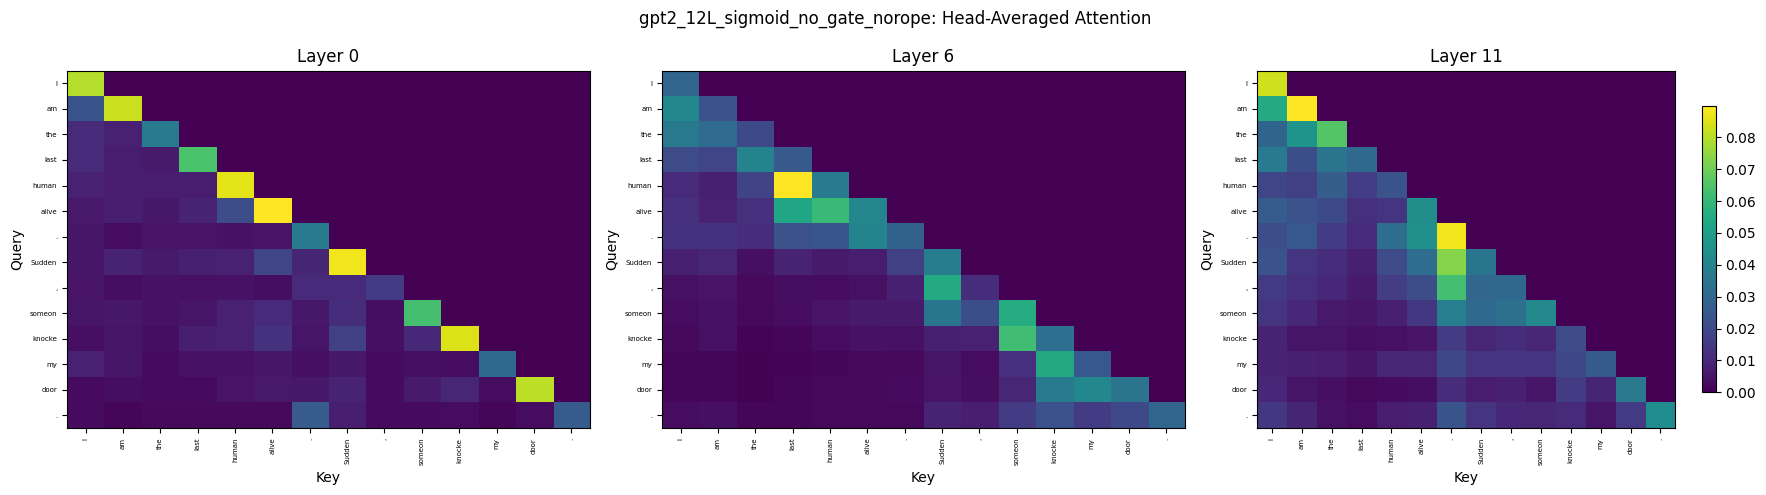

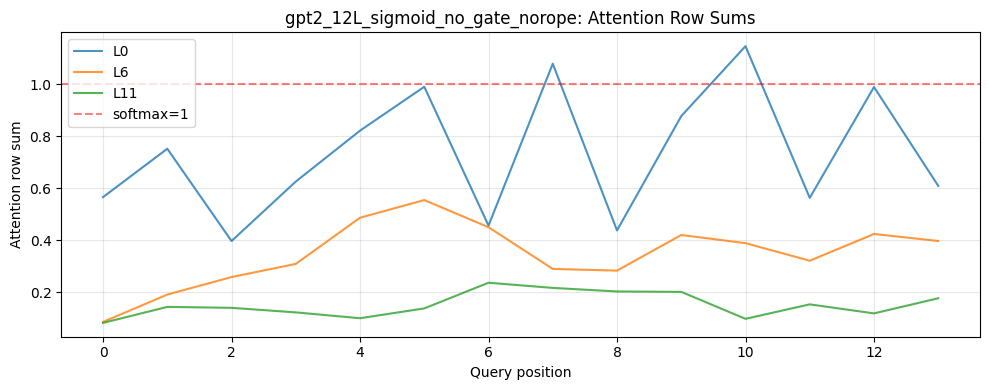

In [ ]:

@torch.no_grad()
def generate(prompt, max_tokens=100, temp=0.8, top_k=50):
    model.eval()
    tokens = tokenizer.encode(prompt, return_tensors="pt").to(device)
    for _ in range(max_tokens):
        if tokens.shape[1] >= cfg.block_size: break
        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            logits = model(tokens)[0][:, -1, :] / temp
        v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
        logits[logits < v[:, [-1]]] = float('-inf')
        tokens = torch.cat([tokens, torch.multinomial(F.softmax(logits, -1), 1)], 1)
    return tokenizer.decode(tokens[0])

print("=" * 60)
print(f"Prompt: {DEMO_PROMPT}")
print("=" * 60)
print(generate(DEMO_PROMPT))
print("=" * 60)

model.eval()
tokens = tokenizer(DEMO_PROMPT, return_tensors="pt").input_ids.to(device)
attn_maps, _ = extract_attention_and_gates(model, tokens)
T = tokens.shape[1]
tok_labels = [tokenizer.decode([tokens[0, i].item()]).strip()[:6] for i in range(T)]

layers_to_show = [0, cfg.n_layer // 2, cfg.n_layer - 1]
fig, axes = plt.subplots(1, len(layers_to_show), figsize=(6 * len(layers_to_show), 5))
for ax, li in zip(axes, layers_to_show):
    A = attn_maps[li][0].mean(0).numpy()  # head-averaged
    im = ax.imshow(A, aspect='auto', cmap='viridis')
    ax.set_title(f"Layer {li}")
    ax.set_xlabel("Key"); ax.set_ylabel("Query")
    if T <= 40:
        ax.set_xticks(range(T)); ax.set_xticklabels(tok_labels, rotation=90, fontsize=5)
        ax.set_yticks(range(T)); ax.set_yticklabels(tok_labels, fontsize=5)
plt.colorbar(im, ax=axes[-1], shrink=0.8)
plt.suptitle(f"{cfg.exp_name}: Head-Averaged Attention", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(cfg.results_dir, f"{cfg.exp_name}_attn_demo.png"), dpi=150)
plt.show()

# Attention row sums
fig, ax = plt.subplots(figsize=(10, 4))
for li in layers_to_show:
    row_sums = attn_maps[li][0].mean(0).sum(-1).numpy()
    ax.plot(row_sums, label=f"L{li}", alpha=0.8)
ax.axhline(1.0, color='red', ls='--', alpha=0.5, label="softmax=1")
ax.set_xlabel("Query position"); ax.set_ylabel("Attention row sum")
ax.set_title(f"{cfg.exp_name}: Attention Row Sums")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(cfg.results_dir, f"{cfg.exp_name}_rowsums.png"), dpi=150)
plt.show()

In [ ]:
torch.save({"model_state_dict": model.state_dict(), "config": asdict(cfg),
            "history": history, "n_params": n_params, "train_time_sec": train_time,
            "final_eval": {"loss": final_ev["loss"], "ppl": final_ev["ppl"]}},
           os.path.join(cfg.save_dir, f"{cfg.exp_name}.pt"))
print(f"Saved to {cfg.save_dir}/{cfg.exp_name}.pt")

Saved to /content/drive/MyDrive/SigEvict/models/gpt2_12L_sigmoid_no_gate_norope.pt


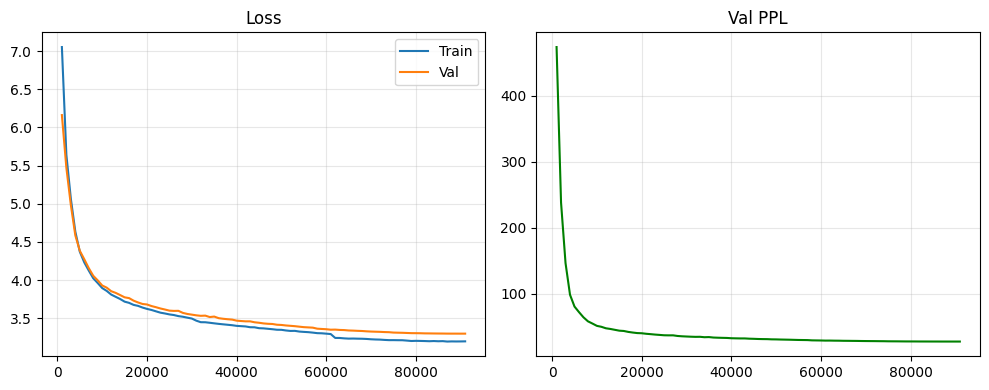

Final PPL: 27.11


In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.plot(history["step"], history["train_loss"], label="Train")
plt.plot(history["step"], history["val_loss"], label="Val")
plt.legend(); plt.title("Loss"); plt.grid(alpha=0.3)
plt.subplot(1,2,2)
plt.plot(history["step"], history["val_ppl"], color="green")
plt.title("Val PPL"); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(cfg.results_dir, f"{cfg.exp_name}_curves.png"), dpi=150)
plt.show()
print(f"Final PPL: {final_ev['ppl']:.2f}")